In [25]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv
import operator


In [26]:
model=ChatOpenAI(model="gpt-5-mini")



In [27]:
class sentimentschema(BaseModel):
    sentiment:Literal["positive","negetive"] = Field(description= "semtiment of the resume ")
    
class run_diagnosis_schema(BaseModel):#for getting a st output for run_diagnosis function and add it to state lator
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [28]:
structured_model= model.with_structured_output(sentimentschema)
structured_model2=model.with_structured_output(run_diagnosis_schema)

In [29]:
class WorkflowState(TypedDict):
    review=str
    sentiment:Literal["positive","negetive"]
    diagnosis: dict
    response:str


In [30]:
def find_sentiment(state:WorkflowState):
    prompt= f'for the following review find the sentiment \n {state["review"]}'
    sentiment=structured_model.invoke(prompt).sentiment
    return {"sentiment":sentiment}
def check_condition(state:WorkflowState)-> Literal["run_diagnosis","positive_response"]:
    if state["sentiment"]=="positive":
        return "positive_response"
    else:
        return "run_diagnosis"
def positive_response(state:WorkflowState):
    prompt= f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n 
    Also, kindly ask the user to leave feedback on our website."""
    response= structured_model.invoke(prompt)
    return {"response": response}

def run_diagnosis(state:WorkflowState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
    """
    diagnosis= structured_model2.invoke(prompt)
    return {"diagnosis": diagnosis.model_dump()}
def negetive_response(state:WorkflowState):
    diagnosis=state["diagnosis"]
    prompt= f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response=model.invoke(prompt).content
    return {"response":response}
    

In [31]:
graph=StateGraph(WorkflowState)
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("positive_response",positive_response)
graph.add_node("negetive_response",negetive_response)

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_condition)
graph.add_edge("positive_response",END)

graph.add_edge("run_diagnosis","negetive_response")
graph.add_edge("negetive_response",END)


workflow=graph.compile()

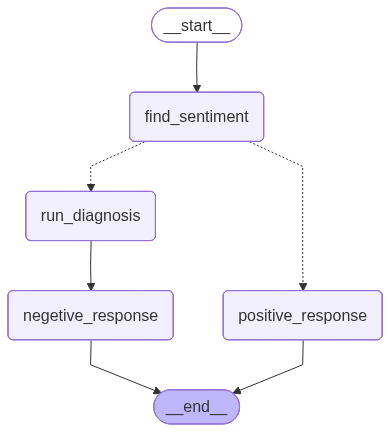

In [32]:
workflow